# Deep learning for rehabilitation assessment with aeon

**ADBIS 2026 tutorial** — [tutorial website](https://aeon-tutorials.github.io/ADBIS-2026/)

A physiotherapist watching a patient perform an exercise does not ask *which* exercise it is, but *how well* it is done. This notebook treats that question as a time series problem. A recording of body joints over time is a multivariate time series; a quality label is a class; a quality score is a regression target.

We use two open resources:

- [**aeon**](https://www.aeon-toolkit.org), a scikit-learn compatible Python toolkit for time series machine learning. Every model, deep or not, is used through `fit` and `predict`.
- [**Rehab-Pile**](https://arxiv.org/abs/2507.21018), an archive of 60 skeleton-based rehabilitation assessment problems with fixed evaluation folds.

No prior knowledge of aeon is assumed.

| Section | Question |
|---|---|
| 1–3 | What is in Rehab-Pile, and what does the data look like? |
| 4–5 | How do I train a deep classifier, and evaluate it soundly? |
| 6 | Which deep learners does aeon offer, and how do they compare with a non-deep baseline? |
| 7 | How do I control and inspect training? |
| 8 | How do I predict a quality score (regression)? |
| 9 | Which part of the movement drives a decision? |
| 10–11 | How do I go beyond the defaults: custom networks and scikit-learn tooling? |
| 12 | Does the same code carry over to clinical data? |

## 0. Setup

The deep learning estimators need TensorFlow, installed with the `dl` extra.

In [1]:
# %pip install -U "aeon[dl]" matplotlib

In [2]:
import os
import time
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # keep TensorFlow quiet
warnings.filterwarnings("ignore")

import aeon
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

tf.keras.utils.disable_interactive_logging()  # no progress bars on predict
tf.get_logger().setLevel("ERROR")
print("aeon", aeon.__version__, "| tensorflow", tf.__version__)

aeon 1.5.0 | tensorflow 2.21.0


`N_EPOCHS` controls the run time. It is deliberately small: the Rehab-Pile benchmark trains for 1500 epochs, so the numbers below are indicative, not a benchmark. With this setting the notebook runs in about 30 minutes on a laptop CPU.

In [3]:
N_EPOCHS = 100  # training epochs per network
SEED = 0  # makes CPU runs reproducible
DATA_DIR = "rehab_pile_data"  # downloaded files are cached here
FIG_DIR = "figures"  # every figure is saved for the slides
os.makedirs(FIG_DIR, exist_ok=True)

A small plotting style, shared by all figures.

In [4]:
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, MUTED, GRID = "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.bbox": "tight",
        "font.size": 13,  # sized for slides as well as for the notebook
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.edgecolor": "#c3c2b7",
        "axes.labelcolor": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "lines.linewidth": 2,
        "legend.frameon": False,
    }
)


def save(fig, name):
    """Save a figure as PDF (slides) and PNG (web)."""
    fig.savefig(f"{FIG_DIR}/{name}.pdf")
    fig.savefig(f"{FIG_DIR}/{name}.png", dpi=200)

## 1. The Rehab-Pile archive

Rehab-Pile gathers existing rehabilitation datasets into one benchmark with a common format. Each *problem* is one exercise from one source dataset, with one of three targets. The name encodes all three, for example `UIPRMD_clf_bn_HS`:

- `UIPRMD`: the source dataset,
- `clf_bn`: binary classification (correct / incorrect). `clf_mc` is multi-class (type of error) and `reg` is regression (clinical score),
- `HS`: the exercise, here a hurdle step.

aeon lists the problems directly.

In [5]:
from aeon.datasets import (
    load_rehab_pile_classification_datasets,
    load_rehab_pile_dataset,
    load_rehab_pile_regression_datasets,
)

clf_names = load_rehab_pile_classification_datasets()
reg_names = load_rehab_pile_regression_datasets()
print(len(clf_names), "classification problems,", len(reg_names), "regression problems")

39 classification problems, 21 regression problems


In [6]:
names = pd.DataFrame({"name": clf_names + reg_names})
names["source"] = names["name"].str.split("_").str[0]
names["task"] = names["name"].str.extract(r"_(clf_bn|clf_mc|reg)_")[0]
names.groupby(["source", "task"]).size().unstack(fill_value=0)

task,clf_bn,clf_mc,reg
source,,,
EHE,0,0,6
IRDS,9,0,0
KERAAL,3,3,0
KIMORE,5,0,5
KINECAL,4,0,0
SPHERE,1,0,0
UCDHE,2,2,0
UIPRMD,10,0,10


## 2. Loading a problem

We follow one exercise through most of the notebook: the **hurdle step** (`HS`) from UI-PRMD. The subject holds a bar on the shoulders and lifts one leg over an imaginary hurdle, keeping the trunk upright. Ten healthy subjects perform the movement several times, correctly and incorrectly. Rehab-Pile provides the problem twice, with the same series and two targets:

- `UIPRMD_clf_bn_HS`: a binary label, correct or incorrect,
- `UIPRMD_reg_HS`: a continuous quality score.

Each problem comes with fixed train/test **folds**. The split is *cross-subject*: nobody appears in both the training and the test set of a fold, which is the condition a deployed system would face.

In [7]:
CLF_PROBLEM, REG_PROBLEM, N_FOLDS = "UIPRMD_clf_bn_HS", "UIPRMD_reg_HS", 7

X_train, y_train, meta = load_rehab_pile_dataset(
    CLF_PROBLEM, split="train", fold=0, extract_path=DATA_DIR, return_meta=True
)
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
meta

X_train: (92, 66, 69) | y_train: (92,)


{'length_TS': 69,
 'n_joints': 22,
 'n_dim': 3,
 'kinematic_tree': [[0, 1, 2, 3, 4, 5],
  [0, 14, 15, 16, 17],
  [0, 18, 19, 20, 21],
  [3, 6, 7, 8, 9],
  [3, 10, 11, 12, 13]],
 'nb_classes': 2}

`X_train` follows the aeon convention for a collection of time series, a 3D array of shape `(n_cases, n_channels, n_timepoints)`:

- 92 recordings, each one repetition of the movement,
- 66 channels: 22 joints × 3 coordinates, channel `3j + d` being coordinate `d` of joint `j`,
- 69 time points: all recordings are resampled to a common length.

The metadata holds the `kinematic_tree`, the chains of joints that form the skeleton.

Two details need care before training:

- Depending on the source dataset, the targets come as a flat vector or as a column. aeon expects the former, so we flatten them.
- Coordinates are in sensor units, a few hundred here, and depend on where the subject stands. Networks train best on inputs of order one. We move the origin to the initial position of the pelvis (joint 0) and divide by 100, about one metre. This keeps the geometry of the skeleton.

The helper below does both and returns the two splits of a fold.

In [8]:
def to_body_units(X, scale):
    """Origin at the initial pelvis position, coordinates divided by `scale`."""
    S = X.reshape(len(X), -1, 3, X.shape[2])  # (n_cases, n_joints, 3, n_timepoints)
    return ((S - S[:, :1, :, :1]) / scale).reshape(X.shape)


def load_fold(name, fold=0, scale=100.0):
    """Return X_train, y_train, X_test, y_test for one fold of a Rehab-Pile problem."""
    X_tr, y_tr = load_rehab_pile_dataset(name, "train", fold, extract_path=DATA_DIR)
    X_te, y_te = load_rehab_pile_dataset(name, "test", fold, extract_path=DATA_DIR)
    return to_body_units(X_tr, scale), y_tr.ravel(), to_body_units(X_te, scale), y_te.ravel()


X_train, y_train, X_test, y_test = load_fold(CLF_PROBLEM)
_, score_train, _, score_test = load_fold(REG_PROBLEM)
print("train:", X_train.shape, "| test:", X_test.shape)
print("class counts (train):", dict(zip(*np.unique(y_train, return_counts=True))))

train: (92, 66, 69) | test: (18, 66, 69)
class counts (train): {np.int64(0): np.int64(46), np.int64(1): np.int64(46)}


The classes are balanced. The archive does not document which label is which, but the scores settle it: recordings labelled 0 have the higher quality scores, so **0 is a correct execution and 1 an incorrect one**.

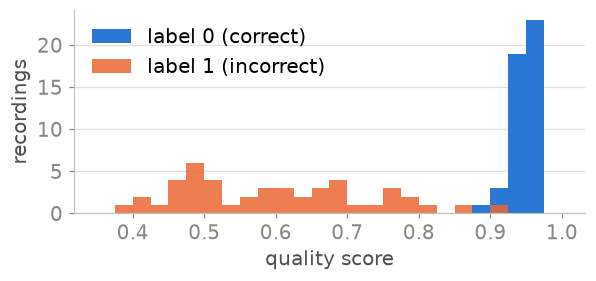

In [9]:
CORRECT, INCORRECT = 0, 1

fig, ax = plt.subplots(figsize=(6, 2.4))
bins = np.linspace(0.35, 1.0, 27)
ax.hist(score_train[y_train == CORRECT], bins=bins, color=BLUE, label="label 0 (correct)")
ax.hist(score_train[y_train == INCORRECT], bins=bins, color=ORANGE, alpha=0.85,
        label="label 1 (incorrect)")
ax.set_xlabel("quality score")
ax.set_ylabel("recordings")
ax.grid(axis="x", visible=False)
ax.legend()
save(fig, "score_distribution")

## 3. Looking at the data

A recording can be read in two ways. As a **skeleton**, it is a body moving in space. As a **multivariate time series**, it is 66 curves. The model only sees the second; the first helps us understand what it has to learn.

In [10]:
TREE = meta["kinematic_tree"]
PELVIS, HEAD, ANKLE = 0, 5, 20  # joint indices used in the plots
SPACING = 1.1  # horizontal distance between two drawn frames


def to_skeleton(x):
    """(n_channels, n_timepoints) -> (n_timepoints, n_joints, 3)."""
    return x.T.reshape(x.shape[1], -1, 3)


def draw_skeleton(ax, frame, color, offset=0.0, tree=TREE, joint_colors=None, size=12):
    """Draw one frame seen from the side: depth (axis 2) against height (axis 1)."""
    for chain in tree:
        ax.plot(frame[chain, 2] + offset, frame[chain, 1], color=color, lw=2,
                solid_capstyle="round")
    ax.scatter(frame[:, 2] + offset, frame[:, 1], s=size, zorder=3, linewidth=0.5,
               c=color if joint_colors is None else joint_colors, edgecolor="white")


def strip(ax, x, color, frames, tree=TREE, spacing=SPACING):
    """Draw several frames of one recording side by side."""
    S = to_skeleton(x)
    for k, t in enumerate(frames):
        draw_skeleton(ax, S[t], color, offset=spacing * k, tree=tree)
    ax.set_aspect("equal")
    ax.set_yticks([])
    ax.grid(False)
    ax.spines["left"].set_visible(False)
    ax.set_xticks(spacing * np.arange(len(frames)), frames)

Below, the best rated correct execution and the worst rated incorrect one, seen from the side.

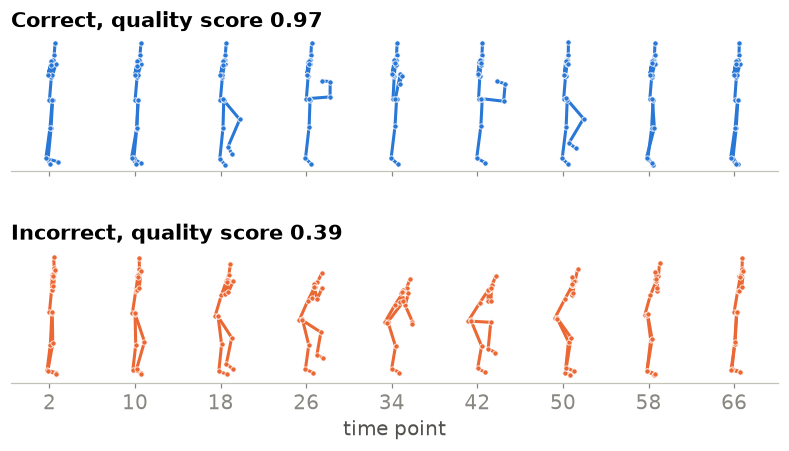

In [11]:
good = np.flatnonzero(y_train == CORRECT)[np.argmax(score_train[y_train == CORRECT])]
bad = np.flatnonzero(y_train == INCORRECT)[np.argmin(score_train[y_train == INCORRECT])]
frames = np.arange(2, X_train.shape[2], 8)

fig, axes = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True, sharey=True)
for ax, i, color, label in zip(axes, (good, bad), (BLUE, ORANGE), ("Correct", "Incorrect")):
    strip(ax, X_train[i], color, frames)
    ax.set_title(f"{label}, quality score {score_train[i]:.2f}")
axes[1].set_xlabel("time point")
save(fig, "skeleton_frames")

In the correct execution the trunk stays vertical while the leg rises. In the incorrect one the whole body bends forward and the leg rises less. The same two recordings as time series, for three of the 66 channels:

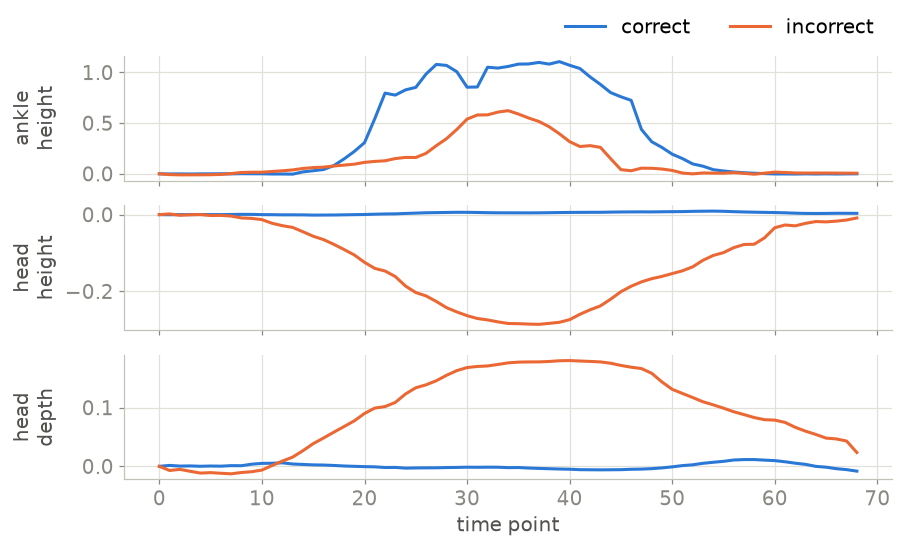

In [12]:
channels = {
    "ankle\nheight": 3 * ANKLE + 1,
    "head\nheight": 3 * HEAD + 1,
    "head\ndepth": 3 * HEAD + 2,
}

fig, axes = plt.subplots(len(channels), 1, figsize=(9, 5), sharex=True)
for ax, (label, c) in zip(axes, channels.items()):
    for i, color, name in ((good, BLUE, "correct"), (bad, ORANGE, "incorrect")):
        ax.plot(X_train[i, c] - X_train[i, c, 0], color=color, label=name)  # change from start
    ax.set_ylabel(label)
axes[0].legend(ncols=2, loc="lower right", bbox_to_anchor=(1, 1))
axes[-1].set_xlabel("time point")
fig.align_ylabels(axes)
save(fig, "series_view")

These two are extreme cases. Over the whole training set, head height flags the grossest errors, but many incorrect executions stay as flat as the correct ones. The model has to combine channels, and find *when* in the movement they differ.

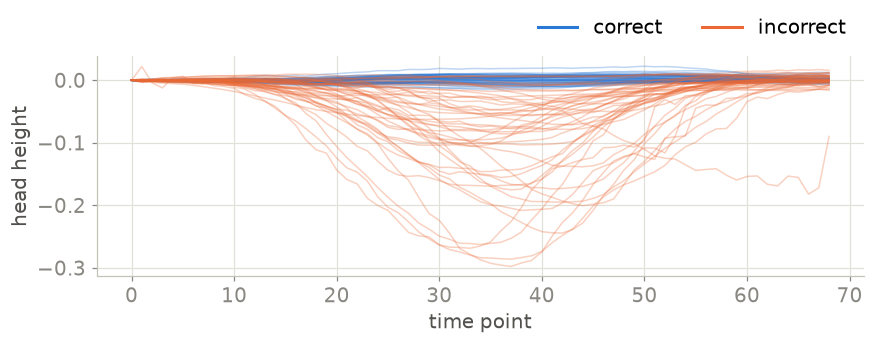

In [13]:
fig, ax = plt.subplots(figsize=(9, 2.6))
c = channels["head\nheight"]
for label, color, name in ((CORRECT, BLUE, "correct"), (INCORRECT, ORANGE, "incorrect")):
    curves = X_train[y_train == label, c]
    ax.plot((curves - curves[:, :1]).T, color=color, alpha=0.3, lw=1)
    ax.plot([], [], color=color, label=name)
ax.set_xlabel("time point")
ax.set_ylabel("head height")
ax.legend(ncols=2, loc="lower right", bbox_to_anchor=(1, 1))
save(fig, "all_series")

## 4. A first deep classifier

We start with the **Fully Convolutional Network** (FCN): three blocks of 1D convolution, batch normalisation and ReLU, then an average over time and a softmax layer. Convolutions slide along the time axis and mix all 66 channels, so the network learns short motion patterns that involve several joints at once.

In aeon a deep network is an estimator like any other: construct, `fit`, `predict`.

In [14]:
from aeon.classification.deep_learning import FCNClassifier

fcn = FCNClassifier(n_epochs=N_EPOCHS, random_state=SEED)
fcn.fit(X_train, y_train)

y_pred = fcn.predict(X_test)
print("predicted:", y_pred)
print("expected: ", y_test)
print("accuracy: ", np.mean(y_pred == y_test).round(2))

predicted: [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1]
expected:  [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1]
accuracy:  1.0


`predict_proba` returns one probability per class, in the order of `fcn.classes_`.

In [15]:
fcn.predict_proba(X_test[:5]).round(2)

array([[0.99, 0.01],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ]], dtype=float32)

There is no tensor, data loader or training loop in sight. aeon converts the array to the Keras layout, one-hot encodes the labels, builds and compiles the network, trains it with Adam, and keeps the weights of the epoch with the lowest training loss. The Keras model remains accessible as `fcn.model_` (Sections 9 and 10).

## 5. Evaluating soundly

The test set of fold 0 holds 18 recordings, from a few of the ten subjects: one error moves accuracy by more than 5 points, and those subjects may be easy or hard. Rehab-Pile therefore defines several folds per problem, 7 for the hurdle step. Their test sets are disjoint and together cover all 110 recordings, so we **pool** the test predictions: every recording is predicted once, by a model that never saw that person.

`evaluate` takes a function that builds a fresh estimator, so that no state leaks between folds.

In [16]:
def evaluate(make_estimator, problem, n_folds=N_FOLDS, scale=100.0):
    """Fit on each fold. Return the pooled test targets and predictions."""
    y_true, y_pred = [], []
    for fold in range(n_folds):
        X_tr, y_tr, X_te, y_te = load_fold(problem, fold, scale)
        estimator = make_estimator().fit(X_tr, y_tr)
        y_true.append(y_te)
        y_pred.append(estimator.predict(X_te))
    return np.concatenate(y_true), np.concatenate(y_pred)

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

y_true, y_pred_fcn = evaluate(
    lambda: FCNClassifier(n_epochs=N_EPOCHS, random_state=SEED), CLF_PROBLEM
)
print(f"accuracy over {len(y_true)} recordings: {accuracy_score(y_true, y_pred_fcn):.2f}")

accuracy over 110 recordings: 0.87


Fold 0 alone suggested a perfect classifier. Over all folds the accuracy is 0.87, and the confusion matrix shows where the errors are.

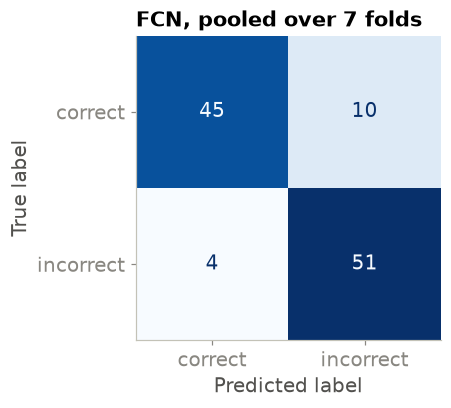

In [18]:
fig, ax = plt.subplots(figsize=(4, 3.6))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_fcn, display_labels=["correct", "incorrect"], cmap="Blues",
    colorbar=False, ax=ax,
)
ax.grid(False)
ax.set_title(f"FCN, pooled over {N_FOLDS} folds")
save(fig, "confusion_fcn")

## 6. A tour of the deep learners

FCN is one of several architectures in `aeon.classification.deep_learning`. All were published for time series, and all are used the same way. They differ in what they assume about the data, in size and in cost.

| Estimator | Architecture | Choose it when |
|---|---|---|
| `MLPClassifier` | Three dense layers on the flattened series. No notion of time. | You want a sanity check: a model that ignores temporal structure. |
| `TimeCNNClassifier` | Two small convolution layers with average pooling. | You want the smallest convolutional model. |
| `FCNClassifier` | Three convolution blocks, then a global average over time. | You want a strong, simple default, and explanations through class activation maps (Section 9). |
| `ResNetClassifier` | Three residual blocks of three convolutions. | You have more data and want more depth; shortcuts keep training stable. |
| `EncoderClassifier` | Convolutions followed by an attention layer over time. | You want the network to weight time regions through attention. |
| `InceptionTimeClassifier` | Inception modules: convolutions of length 10, 20 and 40 in parallel, six modules deep, residual links. Ensemble of five networks. | Patterns occur at several time scales; accuracy matters more than cost. `use_custom_filters=True` gives H-InceptionTime, which adds hand-crafted filters. |
| `LITETimeClassifier` | Inception ideas with depthwise separable convolutions. Ensemble of five networks. | Small datasets, limited memory or embedded inference. `use_litemv=True` is the multivariate variant, the best model of the Rehab-Pile benchmark. |
| `DisjointCNNClassifier` | Each block convolves over time, then across channels. | Multivariate series whose channels interact, such as joints of a body. |

Each classifier has a regression twin in `aeon.regression.deep_learning`, plus `RecurrentRegressor` (LSTM, GRU). The same backbones serve clustering in `aeon.clustering.deep_learning`.

We fit every model once on fold 0 and record its size and training time. This is a profile of the architectures, **not an accuracy benchmark**: that exists already (Section 6.4). InceptionTime and LITETime are reduced to a single network here (`n_classifiers=1`).

A word on the training budget. aeon's defaults follow the original papers: 1500 to 2000 epochs, batches of 16 to 64. Ours is far smaller, so every network gets the same one: 100 epochs with batches of 16, about 600 gradient steps on 92 recordings. The batch size matters more than it seems. Batch normalisation layers need enough steps for their running statistics to settle; with batches of 64, several of these networks still predict a single class after 100 epochs.

In [19]:
from aeon.classification.deep_learning import (
    DisjointCNNClassifier,
    EncoderClassifier,
    InceptionTimeClassifier,
    LITETimeClassifier,
    MLPClassifier,
    ResNetClassifier,
    TimeCNNClassifier,
)

deep = dict(n_epochs=N_EPOCHS, batch_size=16, random_state=SEED)
models = {
    "MLP": MLPClassifier(**deep),
    "TimeCNN": TimeCNNClassifier(**deep),
    "FCN": FCNClassifier(**deep),
    "ResNet": ResNetClassifier(**deep),
    "Encoder": EncoderClassifier(**deep),
    "Inception": InceptionTimeClassifier(n_classifiers=1, **deep),
    "LITEMV": LITETimeClassifier(n_classifiers=1, use_litemv=True, **deep),
    "DisjointCNN": DisjointCNNClassifier(**deep),
}


def keras_model(estimator):
    """The Keras network of a fitted estimator (the first one for an ensemble)."""
    members = getattr(estimator, "classifiers_", [estimator])
    return members[0].model_


rows = []
for name, model in models.items():
    start = time.perf_counter()
    model.fit(X_train, y_train)
    rows.append(
        {
            "model": name,
            "parameters": keras_model(model).count_params(),
            "fit time (s)": time.perf_counter() - start,
            "fold 0 accuracy": np.mean(model.predict(X_test) == y_test),
        }
    )
profile = pd.DataFrame(rows).set_index("model")
profile.round(2)

,parameters,fit time (s),fold 0 accuracy
model,,,
MLP,2779502,27.78,0.78
TimeCNN,3416,11.18,0.78
FCN,332546,24.12,1.00
ResNet,560770,44.23,1.00
Encoder,3299330,71.35,1.00
Inception,504450,53.07,0.94
LITEMV,109738,81.64,1.00
DisjointCNN,1061186,223.01,1.00


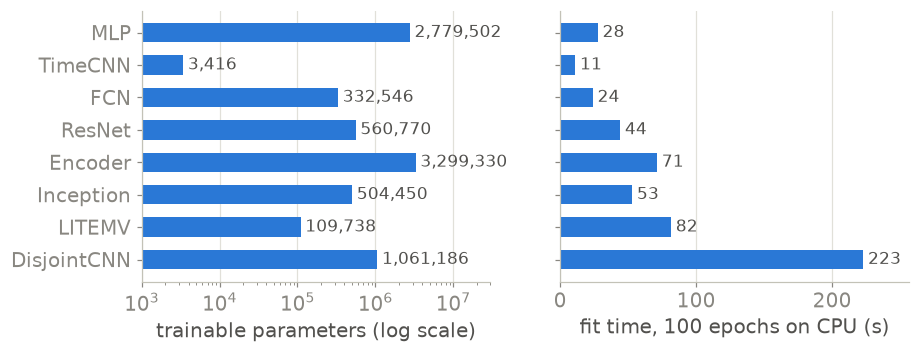

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
order = profile.index[::-1]
for ax, column, label, fmt in zip(
    axes, ("parameters", "fit time (s)"),
    ("trainable parameters (log scale)", f"fit time, {N_EPOCHS} epochs on CPU (s)"),
    ("{:,.0f}", "{:.0f}"),
):
    bars = ax.barh(order, profile.loc[order, column], color=BLUE, height=0.6)
    ax.bar_label(bars, labels=[fmt.format(v) for v in profile.loc[order, column]],
                 padding=3, color=INK, fontsize=11)
    ax.set_xlabel(label)
    ax.grid(axis="y", visible=False)
axes[0].set_xscale("log")
axes[0].set_xlim(1e3, 3e7)
axes[1].margins(x=0.15)
save(fig, "model_profile")

Reading the profile:

- **Size is not depth.** The MLP is the simplest model and one of the largest: dense layers on a flattened 66 × 69 input cost millions of weights. Convolutions share weights over time and need far fewer.
- **LITEMV is the smallest of the competitive networks**, about a fifth of Inception here. On a CPU this does not make it faster to train, because depthwise separable convolutions are poorly optimised there. Its advantage is the memory footprint, for instance on embedded devices.
- **DisjointCNN is the most expensive**: it convolves over time and over channels separately, at full resolution.
- With a short budget, all of them learn this problem on fold 0. Ranking them takes a benchmark (Section 6.4).

### 6.1 What the architecture buys: robustness to a time shift

Recordings are never perfectly segmented: a movement may start a little earlier or later. We shift the test recordings in time and predict again, without retraining.

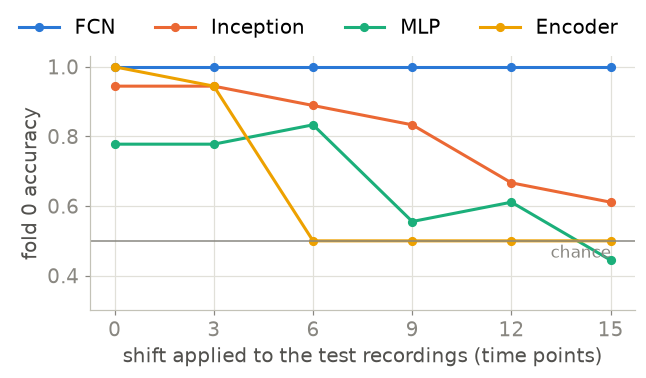

In [21]:
shifts = np.arange(0, 16, 3)
shown = {"FCN": BLUE, "Inception": ORANGE, "MLP": AQUA, "Encoder": YELLOW}

fig, ax = plt.subplots(figsize=(6.4, 3))
for name, color in shown.items():
    accuracy = [np.mean(models[name].predict(np.roll(X_test, s, axis=2)) == y_test)
                for s in shifts]
    ax.plot(shifts, accuracy, color=color, marker="o", markersize=5, label=name)
ax.axhline(0.5, color=MUTED, lw=1)
ax.annotate("chance", (shifts[-1], 0.5), xytext=(0, -11), textcoords="offset points",
            ha="right", color=MUTED, fontsize=11)
ax.set_xticks(shifts)
ax.set_xlabel("shift applied to the test recordings (time points)")
ax.set_ylabel("fold 0 accuracy")
ax.set_ylim(0.3, 1.03)
ax.legend(ncols=4, loc="lower right", bbox_to_anchor=(1, 1))
save(fig, "shift_robustness")

FCN averages its feature maps over time, so *where* a pattern occurs does not matter: its predictions do not move. ResNet and DisjointCNN end the same way and behave the same. Inception and LITEMV share this design, but their longest filters span 40 time points, more than half of a recording: what happens at the borders, including the artificial wrap-around of the shift, reaches most of their outputs. The MLP and the Encoder tie each weight to a time position, and fail when the movement is not where they learned it.

### 6.2 Ensembles

A network's result depends on its random initialisation. InceptionTime and LITETime therefore train several networks and average their probabilities. `n_classifiers` sets how many (five by default); the members stay accessible.

In [22]:
ensemble = InceptionTimeClassifier(n_classifiers=3, **deep)
ensemble.fit(X_train, y_train)

members = np.stack([m.predict_proba(X_test)[:, INCORRECT] for m in ensemble.classifiers_])
for k, p in enumerate(members):
    print(f"member {k}: accuracy {np.mean((p > 0.5) == y_test):.2f}")
print(f"ensemble: accuracy {np.mean(ensemble.predict(X_test) == y_test):.2f}")
print(f"largest disagreement between members on one recording: {np.ptp(members, axis=0).max():.2f}")

member 0: accuracy 0.94
member 1: accuracy 1.00
member 2: accuracy 1.00
ensemble: accuracy 1.00
largest disagreement between members on one recording: 0.93


### 6.3 A non-deep alternative with the same interface

aeon is not a deep learning library: it holds most families of time series algorithms behind the same interface. **RDST** is a convenient counterpart to the networks above. It samples random *shapelets*, short subsequences taken from the training series with a dilation, describes each series by how well and where every shapelet matches, and fits a linear classifier on these features. There are no epochs, no learning rate and no GPU; it suits small datasets and gives a fast reference point.

In [23]:
from aeon.classification.shapelet_based import RDSTClassifier

rdst = RDSTClassifier(random_state=SEED, n_jobs=-1)
start = time.perf_counter()
rdst.fit(X_train, y_train)
print(f"fit in {time.perf_counter() - start:.0f} s"
      f" | fold 0 accuracy {np.mean(rdst.predict(X_test) == y_test):.2f}")

fit in 13 s | fold 0 accuracy 1.00


### 6.4 Which one is the most accurate?

That question needs many problems, several runs and a full training budget. The Rehab-Pile benchmark did exactly this: 60 problems, 1500 epochs, ensembles of five networks. Its results are public, so we read them instead of recomputing them. Four of its nine architectures are available in aeon.

In [24]:
RESULTS = "https://raw.githubusercontent.com/MSD-IRIMAS/DeepRehabPile/main/results/"
published = pd.read_csv(RESULTS + "accuracy_ensemble.csv").groupby("dataset").mean()
published = published.drop(columns="fold")
in_aeon = ["FCN", "H-Inception", "LITEMV", "DisjointCNN"]

print("Published accuracy on", CLF_PROBLEM)
print(published.loc[CLF_PROBLEM, in_aeon].round(2).to_string())

Published accuracy on UIPRMD_clf_bn_HS
FCN            0.81
H-Inception    0.93
LITEMV         0.97
DisjointCNN    0.90


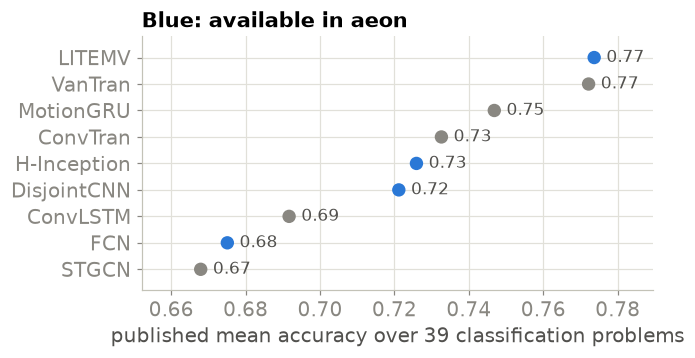

In [25]:
average = published.mean().sort_values()

fig, ax = plt.subplots(figsize=(6, 3))
colors = [BLUE if m in in_aeon else MUTED for m in average.index]
ax.scatter(average, average.index, s=60, color=colors, zorder=3)
for name, value in average.items():
    ax.annotate(f"{value:.2f}", (value, name), xytext=(8, 0), textcoords="offset points",
                va="center", color=INK, fontsize=11)
ax.margins(x=0.15, y=0.1)
ax.set_xlabel(f"published mean accuracy over {len(published)} classification problems")
ax.set_title("Blue: available in aeon")
save(fig, "published_results")

## 7. Controlling and inspecting training

Every deep estimator shares the same training arguments:

| Argument | Role |
|---|---|
| `n_epochs`, `batch_size` | length of training and size of a gradient step |
| `optimizer`, `loss`, `metrics` | any Keras optimizer, loss or metric |
| `callbacks` | any Keras callbacks, e.g. early stopping |
| `save_best_model`, `save_last_model`, `file_path` | keep the trained network on disk |
| `random_state` | reproducible initialisation (on CPU) |
| `verbose` | print the Keras architecture summary and training log |

After `fit`, `summary()` returns the training history. Here is the FCN of Section 4.

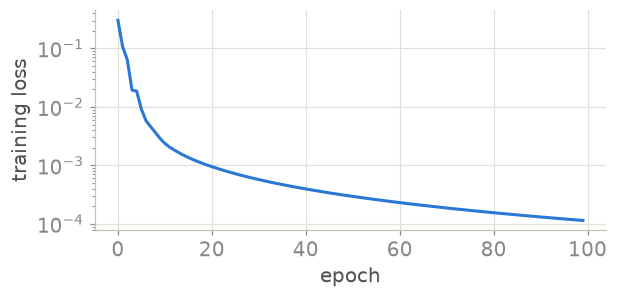

In [26]:
history = fcn.summary()

fig, ax = plt.subplots(figsize=(6, 2.6))
ax.plot(history["loss"], color=BLUE)
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
save(fig, "training_loss")

The next model changes the optimizer, stops when the loss has not improved for 30 epochs, and saves its best weights.

In [27]:
os.makedirs("models", exist_ok=True)
fcn_custom = FCNClassifier(
    n_epochs=N_EPOCHS,
    batch_size=8,
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="loss", patience=30)],
    save_best_model=True,
    file_path="models/",
    best_file_name="fcn_hurdle_step",
    random_state=SEED,
)
fcn_custom.fit(X_train, y_train)
print("epochs run:", len(fcn_custom.summary()["loss"]))

epochs run: 100


A saved network can be loaded into a new estimator, without training.

In [28]:
fcn_loaded = FCNClassifier()
fcn_loaded.load_model("models/fcn_hurdle_step.keras", classes=fcn_custom.classes_)
print("same predictions:", np.array_equal(fcn_loaded.predict(X_test), fcn_custom.predict(X_test)))

same predictions: True


Note that aeon trains on the whole training set and monitors the *training* loss: it does not hold out validation data. With so few recordings this is a reasonable default. Model selection is done from outside, with cross-validation (Section 11).

## 8. Regression: predicting the quality score

A binary label discards most of the assessment. Predicting the score itself is a **time series extrinsic regression** problem: the input is a series, the output a number. In aeon only the import changes, and `evaluate` works as is.

The reference to beat is the mean training score, given by `DummyRegressor`: a model that has learned nothing about the movement.

In [29]:
from aeon.regression import DummyRegressor
from aeon.regression.deep_learning import FCNRegressor
from aeon.regression.shapelet_based import RDSTRegressor
from sklearn.metrics import mean_absolute_error

regressors = {
    "Mean score": lambda: DummyRegressor(),
    "RDST (shapelets)": lambda: RDSTRegressor(random_state=SEED, n_jobs=-1),
    "FCN": lambda: FCNRegressor(**deep),  # same training budget as in Section 6
}

rows, predictions = [], {}
for name, make in regressors.items():
    score_true, predictions[name] = evaluate(make, REG_PROBLEM)
    rows.append(
        {
            "model": name,
            "MAE": mean_absolute_error(score_true, predictions[name]),
            "correlation": np.corrcoef(score_true, predictions[name])[0, 1],
        }
    )
reg_results = pd.DataFrame(rows).set_index("model")
reg_results.round(3)

,MAE,correlation
model,,
Mean score,0.184,-0.143
RDST (shapelets),0.084,0.853
FCN,0.095,0.823


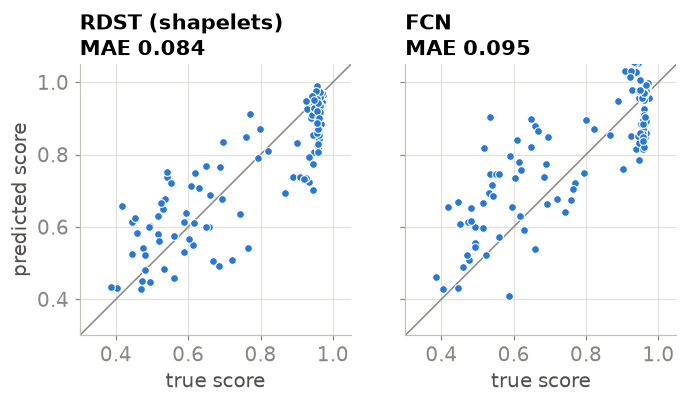

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.8), sharex=True, sharey=True)
lims = [0.3, 1.05]
for ax, name in zip(axes, ["RDST (shapelets)", "FCN"]):
    ax.plot(lims, lims, color=MUTED, lw=1)
    ax.scatter(score_true, predictions[name], s=26, color=BLUE, edgecolor="white",
               linewidth=0.7, zorder=3)
    ax.set_title(f"{name}\nMAE {reg_results.loc[name, 'MAE']:.3f}")
    ax.set(xlim=lims, ylim=lims, aspect="equal", xlabel="true score")
axes[0].set_ylabel("predicted score")
save(fig, "regression_scatter")

Both models recover most of the ordering of the recordings, with a correlation above 0.8 and half the error of the mean score. (The correlation of the mean predictor itself is not meaningful: its prediction only changes from fold to fold.) At this budget RDST matches the network for a fraction of the cost. On small data, a non-deep reference is worth its one line.

## 9. Which part of the movement drives the decision?

A clinician will ask why an execution was judged incorrect. FCN allows a simple answer. Its last convolution block outputs feature maps $A_k(t)$, which are averaged over time and combined linearly into one value per class. Applying the class weights $w_k^c$ *before* the average gives the **class activation map** (CAM):

$$\mathrm{CAM}_c(t) = \sum_k w_k^c \, A_k(t)$$

It is the contribution of each time point to class $c$. The fitted Keras model is available as `model_`, so this takes a few lines.

In [31]:
def class_activation_map(classifier, X):
    """Return CAMs of shape (n_cases, n_timepoints, n_classes) for a fitted FCN."""
    model = classifier.model_
    pooling = next(
        layer for layer in model.layers
        if isinstance(layer, tf.keras.layers.GlobalAveragePooling1D)
    )
    feature_maps = tf.keras.Model(model.input, pooling.input)
    A = feature_maps.predict(X.transpose(0, 2, 1))  # (n_cases, n_timepoints, n_filters)
    W = model.layers[-1].get_weights()[0]  # (n_filters, n_classes)
    return A @ W


cam = class_activation_map(fcn, X_test)[:, :, INCORRECT]
cam.shape

(18, 69)

We look at the test recording that the FCN of Section 4 most confidently calls incorrect. The curve is the evidence for "incorrect" over time, aligned with the skeleton.

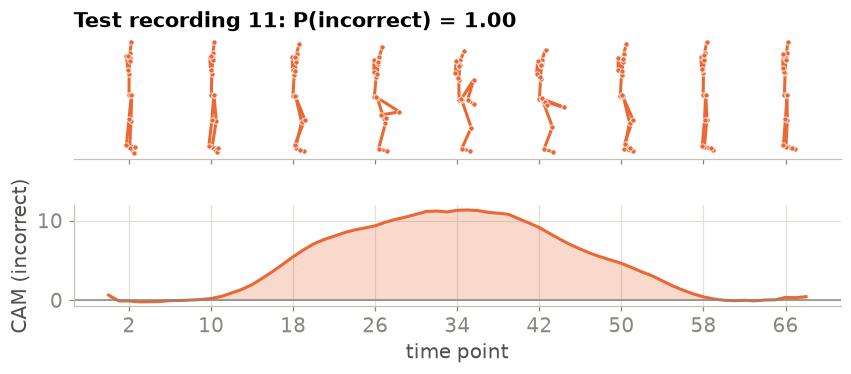

In [32]:
p_incorrect = fcn.predict_proba(X_test)[:, INCORRECT]
i = int(np.argmax(np.where(y_test == INCORRECT, p_incorrect, -1)))
frames = np.arange(2, X_test.shape[2], 8)
t = np.arange(X_test.shape[2])
x_of_t = SPACING * (t - frames[0]) / (frames[1] - frames[0])  # same axis as the strip

fig, (ax_body, ax_cam) = plt.subplots(2, 1, figsize=(9, 3.6), sharex=True,
                                      height_ratios=[1.9, 1], gridspec_kw={"hspace": 0.08})
strip(ax_body, X_test[i], ORANGE, frames)
ax_body.set_title(f"Test recording {i}: P(incorrect) = {p_incorrect[i]:.2f}")
ax_cam.fill_between(x_of_t, 0, cam[i].clip(min=0), color=ORANGE, alpha=0.25, lw=0)
ax_cam.plot(x_of_t, cam[i], color=ORANGE)
ax_cam.axhline(0, color=MUTED, lw=1)
ax_cam.set_ylabel("CAM (incorrect)")
ax_cam.set_xlabel("time point")
save(fig, "cam_example")

Averaged over the test recordings of each class, the maps show when the two classes part: the evidence builds up while the leg is in the air, and the standing phases at both ends carry little.

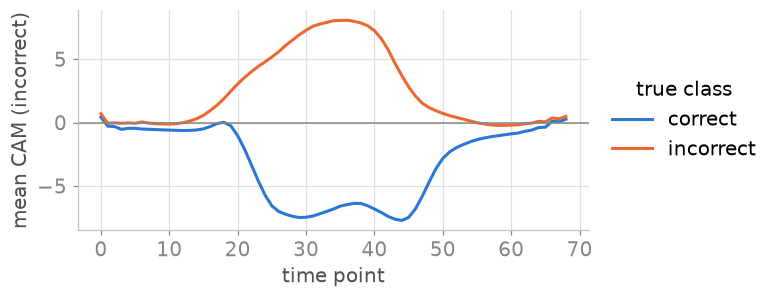

In [33]:
fig, ax = plt.subplots(figsize=(6, 2.6))
for label, color, name in ((CORRECT, BLUE, "correct"), (INCORRECT, ORANGE, "incorrect")):
    ax.plot(cam[y_test == label].mean(axis=0), color=color, label=name)
ax.axhline(0, color=MUTED, lw=1)
ax.set_xlabel("time point")
ax.set_ylabel("mean CAM (incorrect)")
ax.legend(title="true class", loc="center left", bbox_to_anchor=(1.01, 0.5))
save(fig, "cam_mean")

CAM says *when*, not *where on the body*. For that, a model-agnostic test works with any estimator: **occlusion**. Freeze one joint at its mean position, predict again, and measure how much the probability moves.

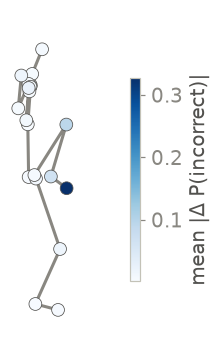

In [34]:
n_joints = X_test.shape[1] // 3
importance = np.zeros(n_joints)
for j in range(n_joints):
    X_occluded = X_test.copy()
    joint = slice(3 * j, 3 * j + 3)
    X_occluded[:, joint] = X_occluded[:, joint].mean(axis=2, keepdims=True)
    shift = fcn.predict_proba(X_occluded)[:, INCORRECT] - p_incorrect
    importance[j] = np.abs(shift).mean()

fig, ax = plt.subplots(figsize=(4.4, 4))
S = to_skeleton(X_test[i])
draw_skeleton(ax, S[X_test.shape[2] // 2], MUTED, joint_colors=importance, size=70)
joints = ax.collections[-1]
joints.set_cmap("Blues")
joints.set_edgecolor(INK)
ax.set_aspect("equal")
ax.margins(0.15)
ax.axis("off")
fig.colorbar(joints, ax=ax, label="mean |Δ P(incorrect)|", shrink=0.6, pad=0.15)
save(fig, "joint_occlusion")

The decision rests on the lifted leg, its foot first. Both views point to where the two executions of Section 3 differ, which is a useful sanity check before trusting a model.

## 10. Beyond the estimators: building on aeon networks

Each estimator wraps a **network** from `aeon.networks`. A network only builds the backbone: `build_network` returns the Keras input and the last hidden layer, and leaves the output layer to you. This is the entry point for anything the estimators do not cover.

Rehab-Pile gives two targets for the same recording: the class and the score. The model below shares one FCN backbone between two heads and learns both at once.

In [35]:
from aeon.networks import FCNNetwork

n_cases, n_channels, n_timepoints = X_train.shape
tf.keras.utils.set_random_seed(SEED)

inputs, features = FCNNetwork().build_network(input_shape=(n_timepoints, n_channels))
incorrect = tf.keras.layers.Dense(1, activation="sigmoid", name="incorrect")(features)
score = tf.keras.layers.Dense(1, activation="sigmoid", name="score")(features)

multitask = tf.keras.Model(inputs, [incorrect, score])
multitask.compile(
    optimizer="adam",
    loss={"incorrect": "binary_crossentropy", "score": "mse"},
)
print(f"{multitask.count_params():,} parameters, {len(multitask.outputs)} outputs")

332,546 parameters, 2 outputs


From here on this is plain Keras. The only aeon-specific step is the layout: aeon stores a series as `(n_channels, n_timepoints)`, Keras expects `(n_timepoints, n_channels)`.

In [36]:
def to_keras(X):
    return X.transpose(0, 2, 1)


multitask.fit(
    to_keras(X_train),
    {"incorrect": y_train, "score": score_train},
    epochs=N_EPOCHS,
    batch_size=16,
    verbose=0,
)
p_incorrect_mt, p_score = (p.ravel() for p in multitask.predict(to_keras(X_test)))
print("accuracy:", np.mean((p_incorrect_mt > 0.5) == y_test).round(2),
      "| MAE:", np.abs(p_score - score_test).mean().round(3))

accuracy: 1.0 | MAE: 0.106


## 11. scikit-learn tooling

aeon estimators follow the scikit-learn estimator contract, so scikit-learn's composition and model selection tools apply to them, 3D input included.

**The official folds as a scikit-learn splitter.** The test sets of the folds partition the recordings. Stacking them, with the fold number of each recording, turns the Rehab-Pile protocol into a `PredefinedSplit`.

In [37]:
from sklearn.model_selection import PredefinedSplit

test_sets = [load_fold(CLF_PROBLEM, fold)[2:] for fold in range(N_FOLDS)]
X_all = np.concatenate([X for X, _ in test_sets])
y_all = np.concatenate([y for _, y in test_sets])
fold_of = np.concatenate([np.full(len(y), fold) for fold, (_, y) in enumerate(test_sets)])
official_folds = PredefinedSplit(fold_of)
print(X_all.shape, "|", official_folds.get_n_splits(), "cross-subject splits")

(110, 66, 69) | 7 cross-subject splits


**Pipelines.** aeon transformers and deep estimators chain in a scikit-learn pipeline. `Centerer` subtracts from every channel its mean over time, which removes where the person stood in the room. `cross_val_score` then runs the whole protocol.

In [38]:
from aeon.transformations.collection import Centerer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(Centerer(), FCNClassifier(**deep))
fold_accuracy = cross_val_score(pipeline, X_all, y_all, cv=official_folds)
print("accuracy per fold:", fold_accuracy.round(2), "| mean:", fold_accuracy.mean().round(2))

accuracy per fold: [1.   1.   0.94 0.94 1.   0.93 0.92] | mean: 0.96


Centring helps here: the mean accuracy is 0.96, against 0.87 for the same network without it (Section 5).

**Hyper-parameter search.** Architecture arguments are ordinary parameters. Here the search compares two network widths, with a halved training to save time, hence the lower scores.

In [39]:
from sklearn.model_selection import GridSearchCV

search = GridSearchCV(
    FCNClassifier(n_epochs=N_EPOCHS // 2, random_state=SEED),
    param_grid={"n_filters": [[32, 64, 32], [128, 256, 128]]},
    cv=official_folds,
    refit=False,
)
search.fit(X_all, y_all)
pd.DataFrame(search.cv_results_)[["param_n_filters", "mean_test_score", "std_test_score"]].round(2)

,param_n_filters,mean_test_score,std_test_score
0,"[32, 64, 32]",0.77,0.20
1,"[128, 256, 128]",0.60,0.15


One caution. Rehab-Pile does not ship subject identifiers, so a random split such as `KFold` would put recordings of the same person on both sides and overestimate accuracy. Stay with the official folds.

## 12. The same code on clinical data

UI-PRMD is a controlled setting: healthy subjects, deliberate errors. **KIMORE** is closer to the clinic. It records 71 people, 31 of them patients with motor dysfunctions, and an expert rates every recording from 0 to 100. We take its squat exercise. The binary version of the problem labels a recording as correct when the score exceeds 50.

In [40]:
X_k, score_k, meta_k = load_rehab_pile_dataset(
    "KIMORE_reg_Sq", split="train", fold=0, extract_path=DATA_DIR, return_meta=True
)
X_k, score_k = to_body_units(X_k, scale=1.0), score_k.ravel()  # KIMORE is in metres
print("X:", X_k.shape, "| scores from", score_k.min().round(1), "to", score_k.max())

X: (64, 54, 557) | scores from 6.7 to 100.0


The recordings are longer (557 time points, five squats each) and come from another sensor with 18 joints. The helpers of Section 3 only need the new kinematic tree.

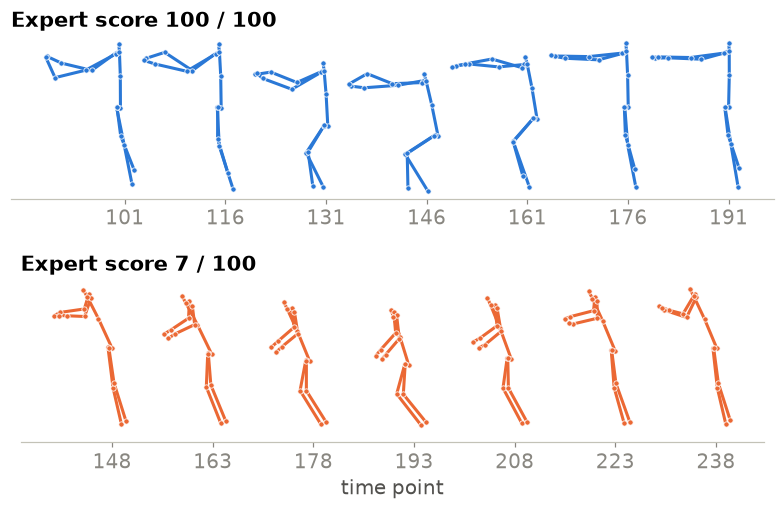

In [41]:
best, worst = int(np.argmax(score_k)), int(np.argmin(score_k))

fig, axes = plt.subplots(2, 1, figsize=(9, 4.8), sharey=True, gridspec_kw={"hspace": 0.5})
for ax, i, color in zip(axes, (best, worst), (BLUE, ORANGE)):
    hip_height = X_k[i, 3 * PELVIS + 1]
    deepest = 40 + int(np.argmin(hip_height[40:200]))  # bottom of the first squat
    strip(ax, X_k[i], color, deepest + np.arange(-45, 46, 15),
          tree=meta_k["kinematic_tree"], spacing=0.9)
    ax.set_title(f"Expert score {score_k[i]:.0f} / 100")
axes[1].set_xlabel("time point")
save(fig, "kimore_skeletons")

Two adjustments, both one-liners:

- `DownsampleTransformer`, an aeon transformer, keeps one time point in four. A squat is slow, and training becomes four times cheaper. It chains with any estimator in a pipeline.
- `TransformedTargetRegressor`, from scikit-learn, rescales the 0 to 100 score to [0, 1] for training and maps predictions back.

In [42]:
from aeon.transformations.collection import DownsampleTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import MinMaxScaler


def downsample():
    return DownsampleTransformer(downsample_by="proportion", proportion=0.75)


kimore_models = {
    "Mean score": lambda: DummyRegressor(),
    "RDST (shapelets)": lambda: make_pipeline(
        downsample(), RDSTRegressor(random_state=SEED, n_jobs=-1)
    ),
    "FCN": lambda: make_pipeline(
        downsample(),
        TransformedTargetRegressor(FCNRegressor(**deep), transformer=MinMaxScaler()),
    ),
}

rows = []
for name, make in kimore_models.items():
    k_true, k_pred = evaluate(make, "KIMORE_reg_Sq", n_folds=5, scale=1.0)
    rows.append({"model": name, "MAE": mean_absolute_error(k_true, k_pred),
                 "correlation": np.corrcoef(k_true, k_pred)[0, 1]})
pd.DataFrame(rows).set_index("model").round(2)

,MAE,correlation
model,,
Mean score,21.73,-0.36
RDST (shapelets),16.99,0.34
FCN,27.44,0.26


Read the table with the folds in mind. The five test sets hold 31 recordings, all from patients; the 40 recordings of healthy subjects are always in the training set. The models learn from a population and are tested on another. The problem is hard. Here RDST improves on the mean score and the FCN does not; in the published benchmark too, the deep models stay close to the mean score on this problem. Small clinical datasets are where a trivial baseline and a non-deep reference earn their place.

## Take-aways

- **One interface.** A deep network in aeon is an estimator: `fit`, `predict`, `predict_proba`. Classification and regression differ by an import. Deep and non-deep models are interchangeable, which makes honest baselines cheap.
- **Rehab-Pile is one function call away**, with 60 problems, a common format, skeleton metadata and cross-subject folds.
- **Evaluate over all folds.** Test sets are small; a single fold says little. Pool the predictions or average over folds, and always report a trivial baseline.
- **Nothing is hidden.** Training arguments are Keras objects, the fitted model is `model_`, the backbones are in `aeon.networks`. Class activation maps and a two-headed network each took a few lines.
- **scikit-learn tooling applies**: pipelines, cross-validation with the official folds, grid search, target transformation.

### Going further

- Train longer (`N_EPOCHS = 1500`) and use the full ensembles (`n_classifiers=5`) to approach the published results.
- Try the other 58 problems: only the names at the top of Section 2 change.
- aeon documentation: [deep learning examples](https://www.aeon-toolkit.org/en/stable/examples/networks/deep_learning.html), [API reference](https://www.aeon-toolkit.org/en/stable/api_reference.html).

### References

- A. Ismail-Fawaz, M. Devanne, S. Berretti, J. Weber, G. Forestier. *Deep learning for skeleton based human motion rehabilitation assessment: a benchmark.* arXiv:2507.21018, 2025.
- M. Middlehurst et al. *aeon: a Python toolkit for learning from time series.* JMLR 25(289), 2024.
- Z. Wang, W. Yan, T. Oates. *Time series classification from scratch with deep neural networks: a strong baseline.* IJCNN, 2017. (FCN, ResNet)
- H. Ismail Fawaz et al. *InceptionTime: finding AlexNet for time series classification.* DMKD 34, 2020.
- A. Ismail-Fawaz, M. Devanne, S. Berretti, J. Weber, G. Forestier. *LITE: light Inception with boosting techniques for time series classification.* DSAA, 2023; *Look into the LITE*, IJDSA, 2025. (LITE, LITEMV)
- A. Guillaume, C. Vrain, W. Elloumi. *Random dilated shapelet transform: a new approach for time series shapelets.* ICPRAI, 2022. (RDST)
- B. Zhou, A. Khosla, A. Lapedriza, A. Oliva, A. Torralba. *Learning deep features for discriminative localization.* CVPR, 2016. (CAM)
- A. Vakanski, H. Jun, D. Paul, R. Baker. *A data set of human body movements for physical rehabilitation exercises.* Data 3(1), 2018. (UI-PRMD)
- M. Capecci et al. *The KIMORE dataset: kinematic assessment of movement and clinical scores for remote monitoring of physical rehabilitation.* IEEE TNSRE 27(7), 2019.